# Weak Signal Diagnostic Report

4D skeleton → graph → morphometry pipeline diagnostic. Loads outputs from Phases 2–5 and summarizes findings.

## 1. Setup

Notebook lives in `report/`; paths are relative to this directory.

In [2]:
from pathlib import Path

import pandas as pd

REPORT_DIR = Path()
assert REPORT_DIR.exists(), "Run from report/ directory or set REPORT_DIR"

## 2. Phase 2 – Per-feature QC and Sanity Checks

In [3]:
# QC per feature
MAX_MISSING_PCT = 30
qc = pd.read_csv(REPORT_DIR / "qc_per_feature.csv")
print(f"Features: {len(qc)}")
print(
    f"Constant: {qc['is_constant'].sum()}, High missing (>{MAX_MISSING_PCT}%): {(qc['missing_pct'] > MAX_MISSING_PCT).sum()}"
)
qc.head(10)

Features: 117
Constant: 2, High missing (>30%): 0


,feature,missing_pct,is_constant,nan_count,inf_count,outlier_pct,n_valid
0,component_1__segment__start__mean,0.146199,False,1,0,0.000000,683
1,component_1__segment__start__std,0.146199,False,1,0,0.000000,683
2,component_1__segment__start__min,0.146199,False,1,0,0.000000,683
3,component_1__segment__start__max,0.146199,False,1,0,0.000000,683
4,component_1__segment__start__count,0.146199,False,1,0,1.608187,683
5,component_1__segment__end__mean,0.146199,False,1,0,0.000000,683
6,component_1__segment__end__std,0.146199,False,1,0,0.000000,683
7,component_1__segment__end__min,0.146199,False,1,0,0.000000,683
8,component_1__segment__end__max,0.146199,False,1,0,0.000000,683
9,component_1__segment__end__count,0.146199,False,1,0,1.608187,683


In [4]:
# Sanity violations
vio_path = REPORT_DIR / "sanity_violations.csv"
if vio_path.exists():
    vio = pd.read_csv(vio_path)
    print(f"Sanity violations: {len(vio)}")
    if len(vio) > 0:
        display(vio.head(10))
else:
    print("No sanity_violations.csv")

Sanity violations: 41826


,case_id,feature,value,violation_type,rule,context
0,DUKE_001,radius.sd,0.0,radius_non_positive,radius.sd > 0,1/component_1[1]
1,DUKE_001,radius.sd,0.0,radius_non_positive,radius.sd > 0,1/component_1[2]
2,DUKE_001,radius.sd,0.0,radius_non_positive,radius.sd > 0,1/component_1[3]
3,DUKE_001,radius.sd,0.0,radius_non_positive,radius.sd > 0,1/component_1[5]
4,DUKE_001,radius.sd,0.0,radius_non_positive,radius.sd > 0,1/component_1[16]
5,DUKE_001,radius.sd,0.0,radius_non_positive,radius.sd > 0,1/component_1[24]
6,DUKE_001,radius.sd,0.0,radius_non_positive,radius.sd > 0,1/component_1[25]
7,DUKE_001,radius.sd,0.0,radius_non_positive,radius.sd > 0,1/component_1[26]
8,DUKE_001,radius.sd,0.0,radius_non_positive,radius.sd > 0,1/component_1[28]
9,DUKE_001,radius.sd,0.0,radius_non_positive,radius.sd > 0,1/component_1[29]


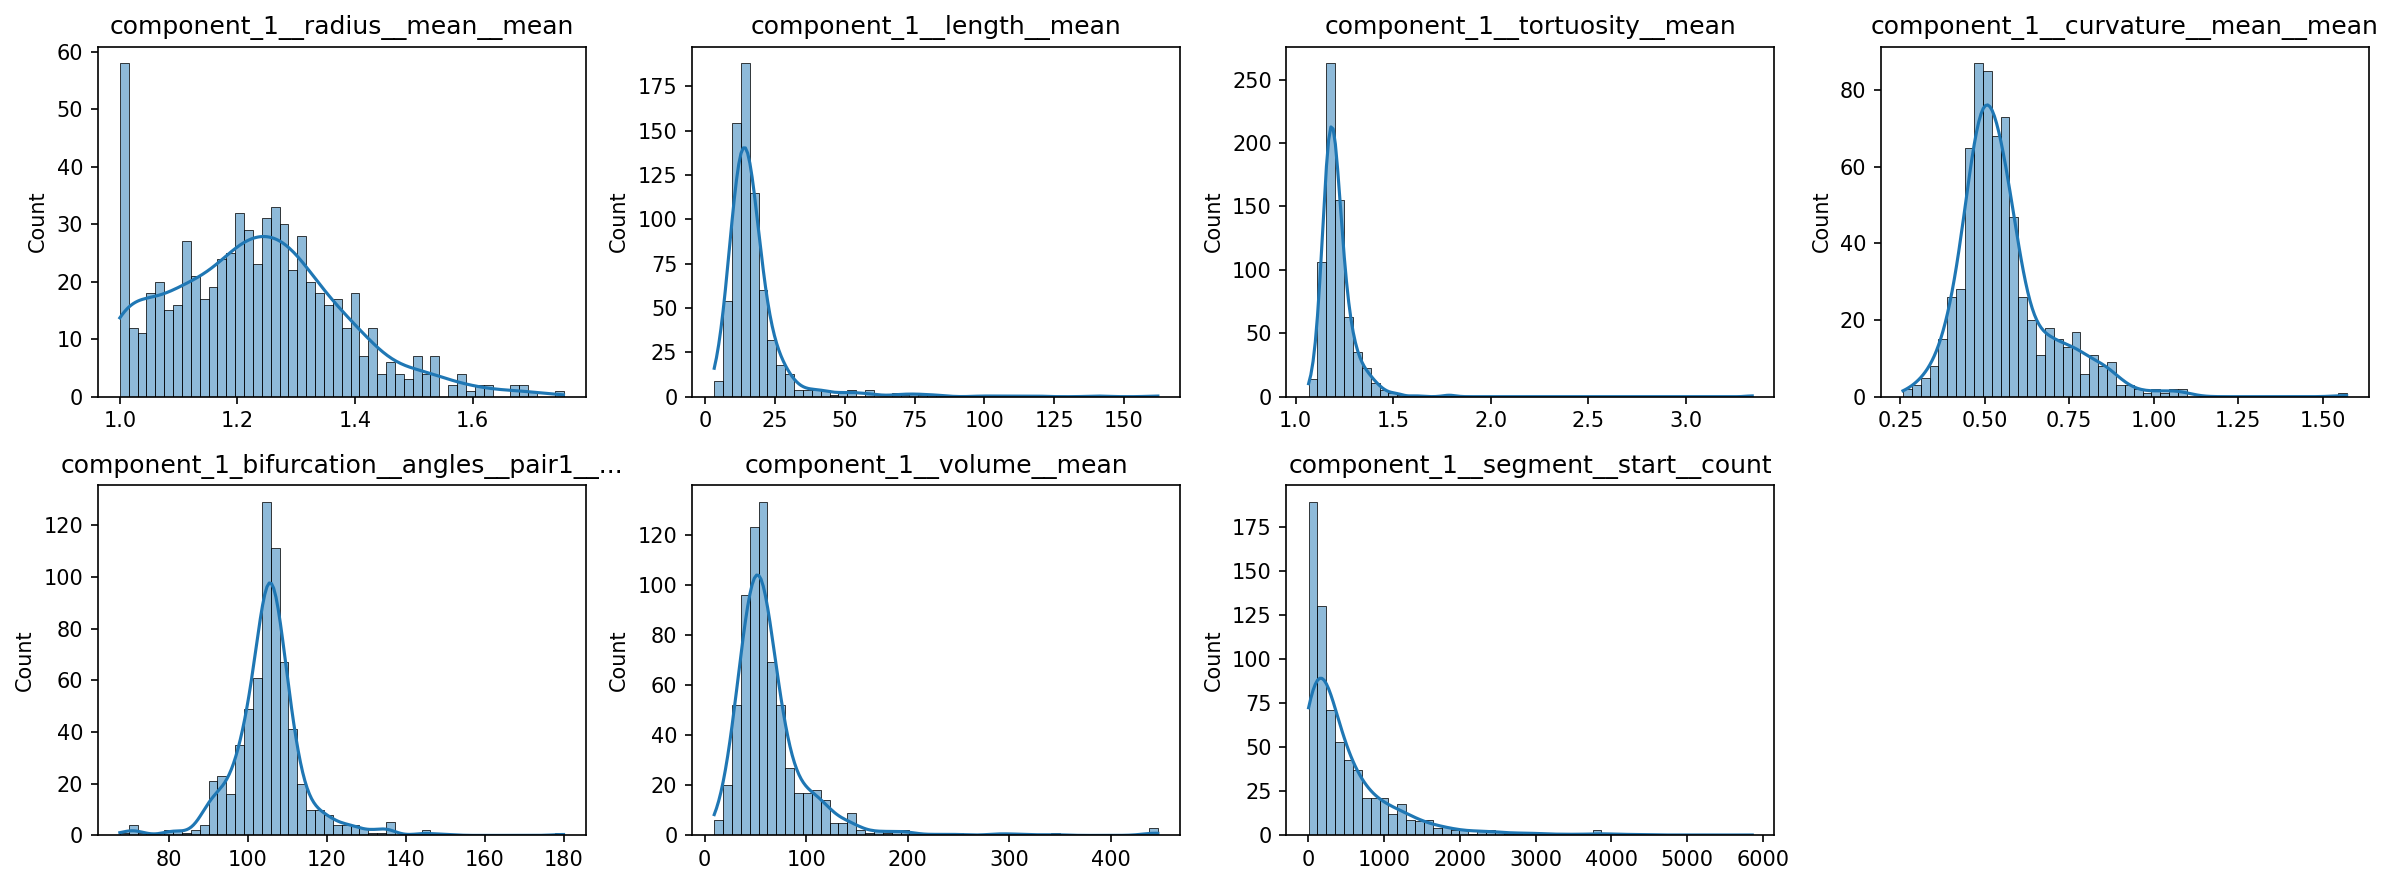

In [5]:
# Distribution plots
from IPython.display import Image, display

dist_path = REPORT_DIR / "plots" / "distributions_core.png"
if dist_path.exists():
    display(Image(filename=str(dist_path), width=800))

## 3. Phase 3 – Batch Effect and Nuisance Analysis

### Colored by pcr


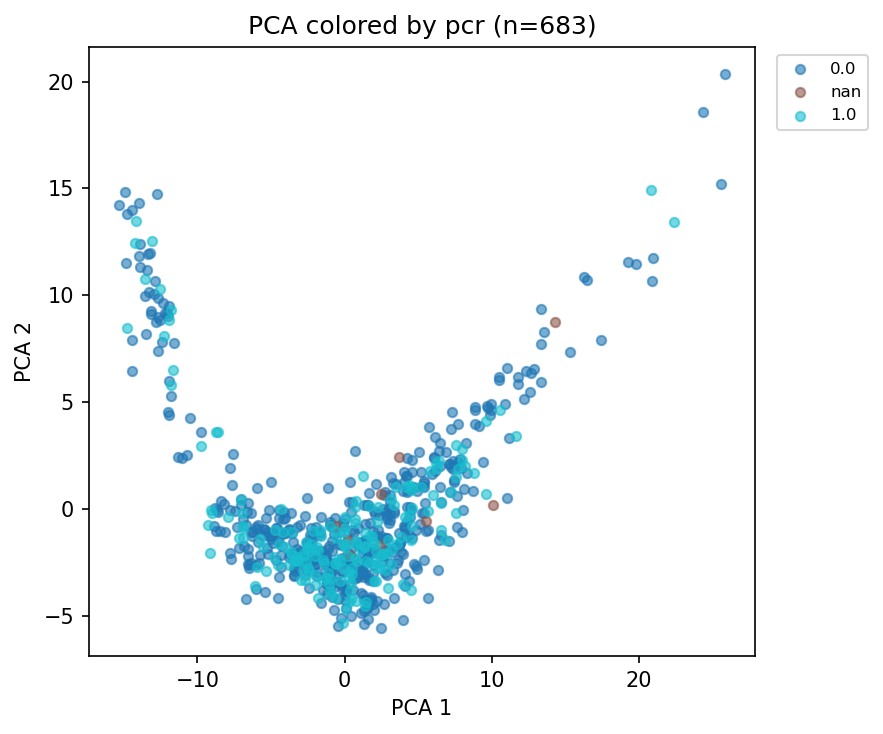

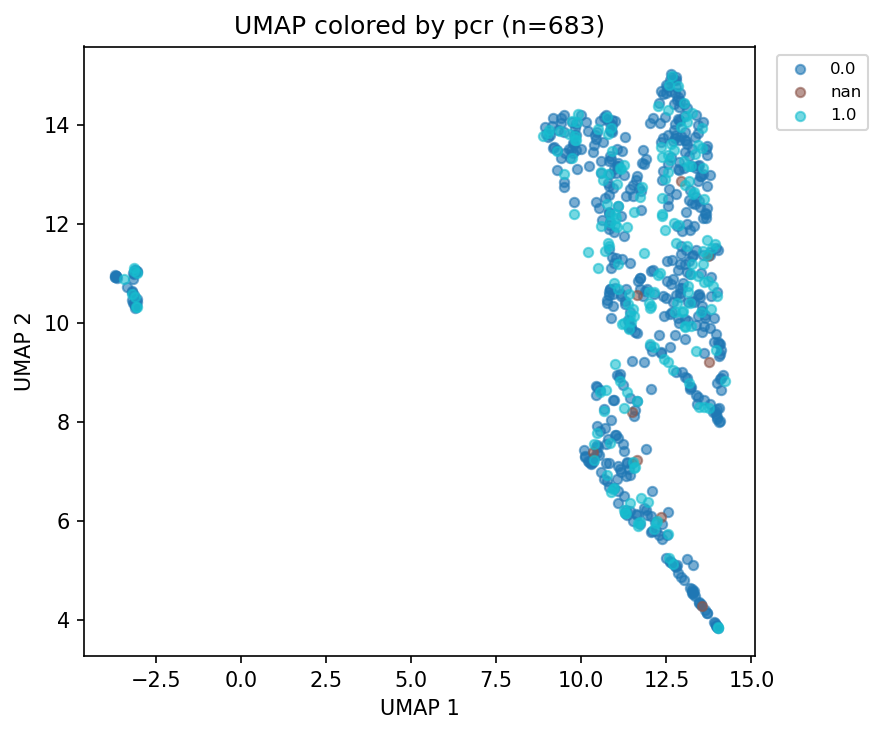

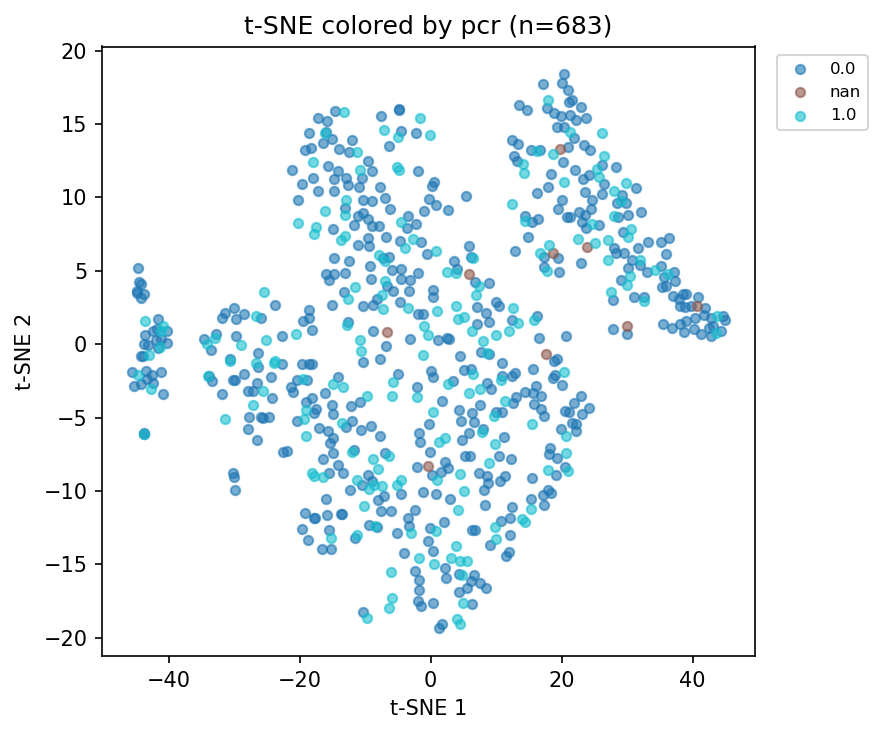

### Colored by site


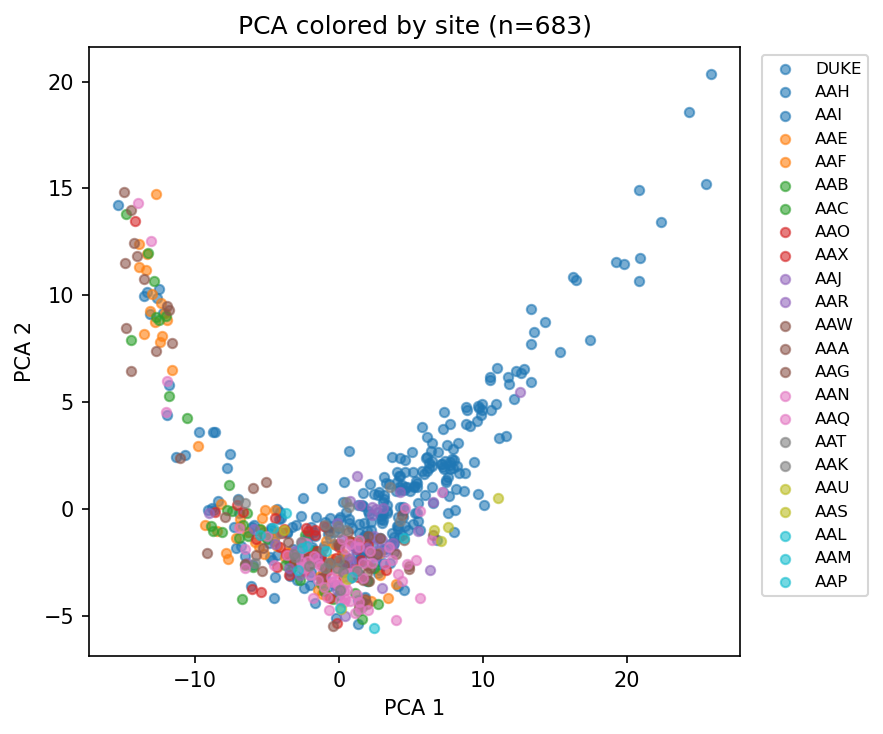

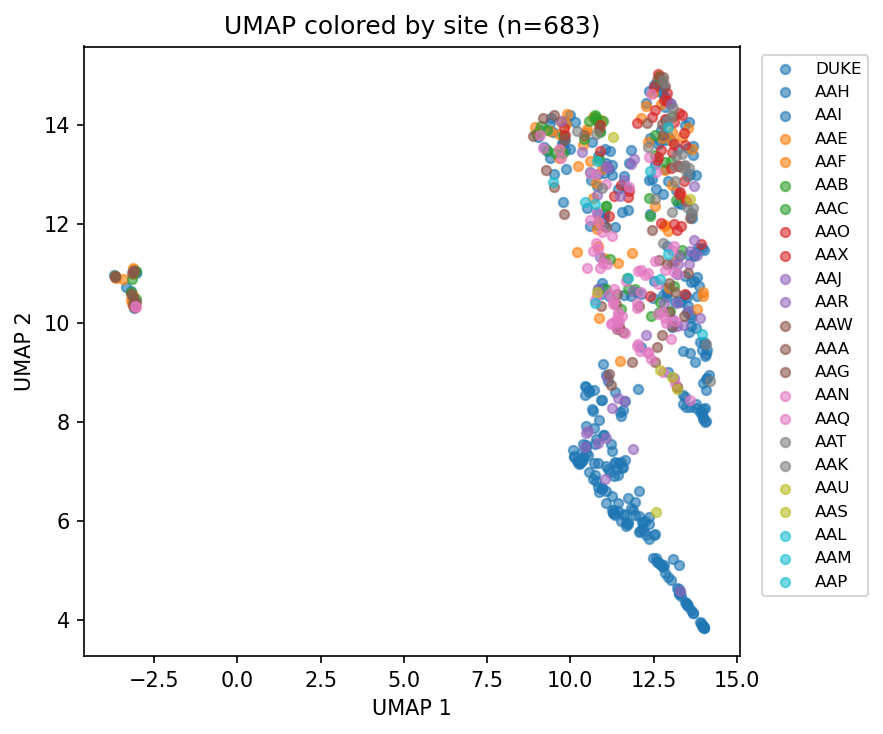

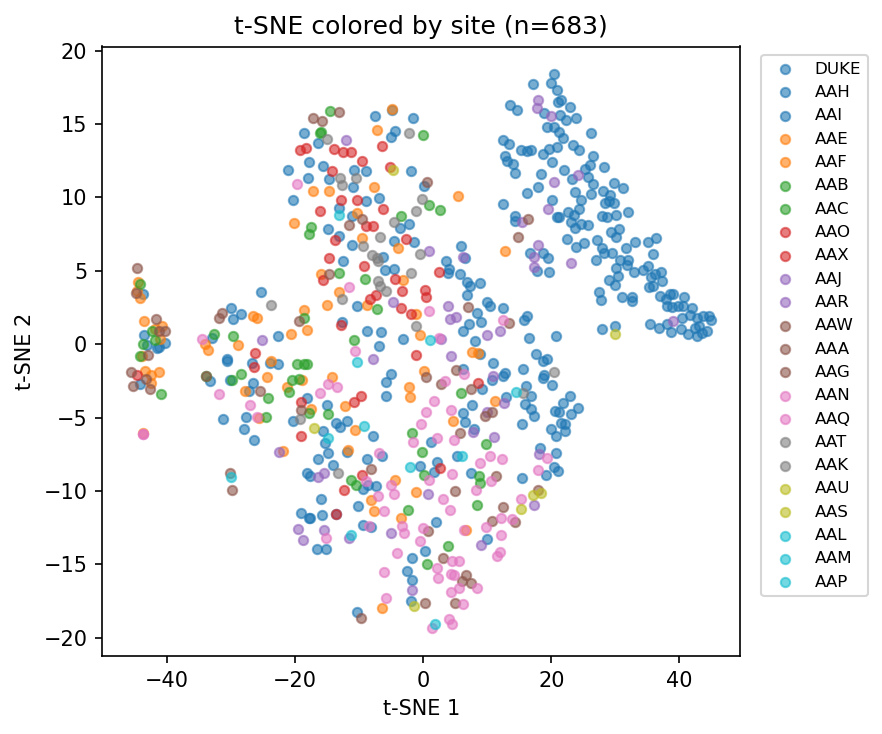

### Colored by dataset


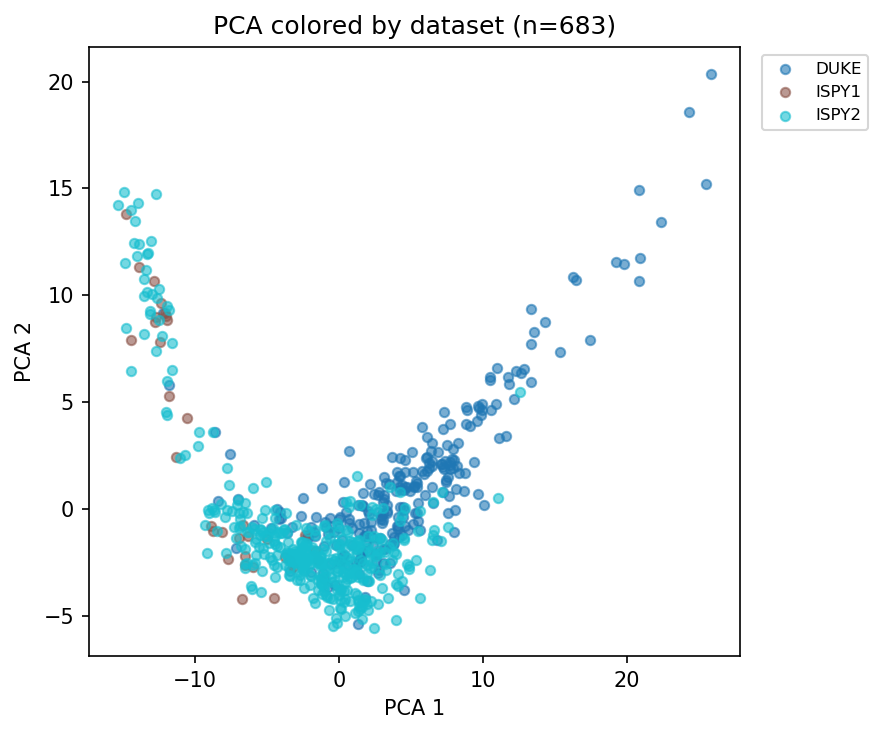

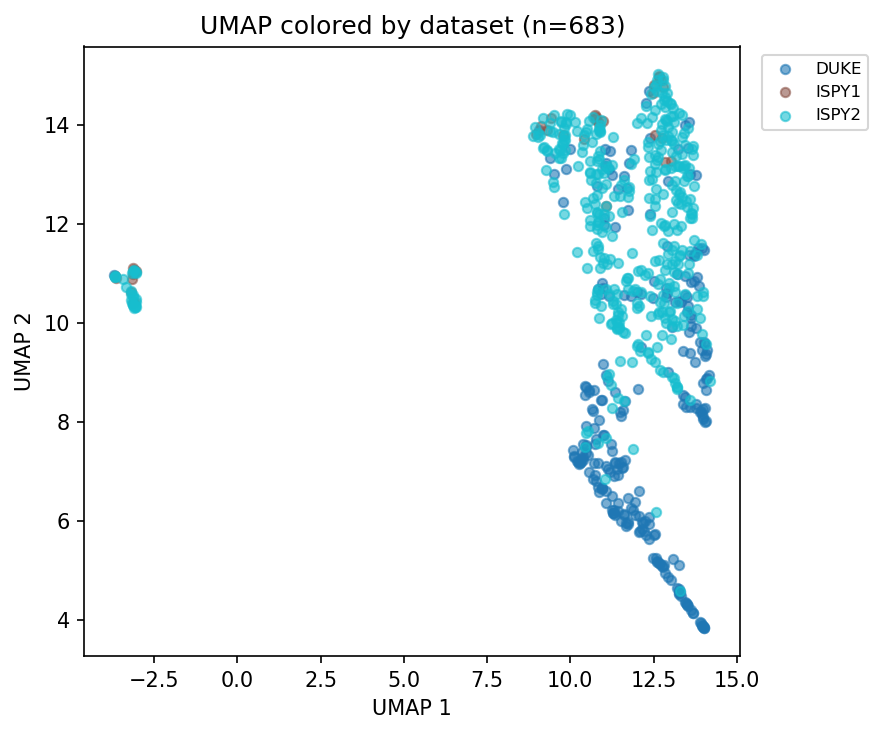

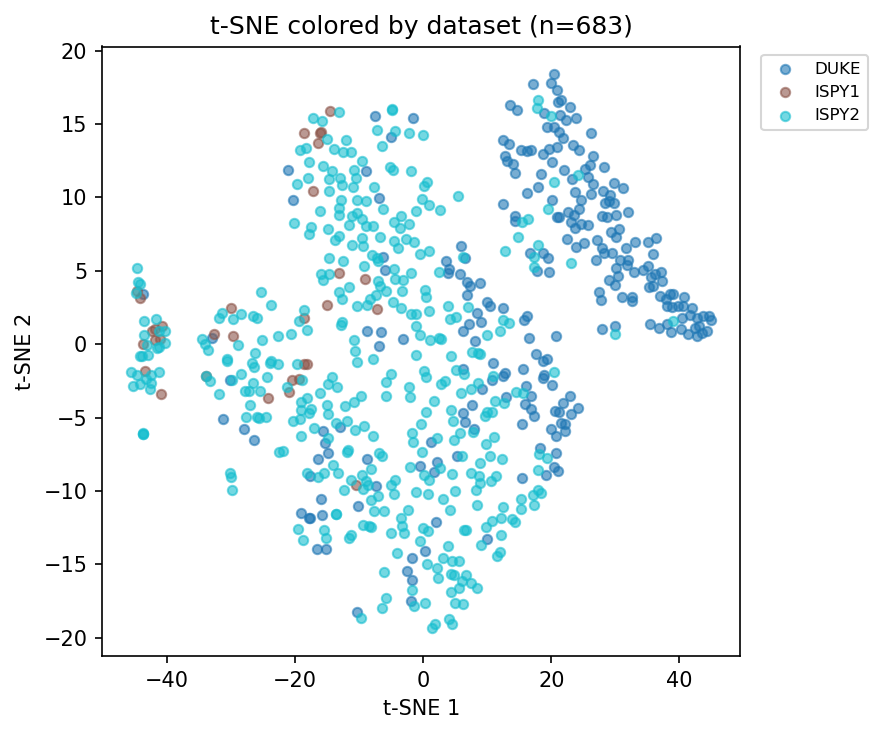

### Colored by manufacturer


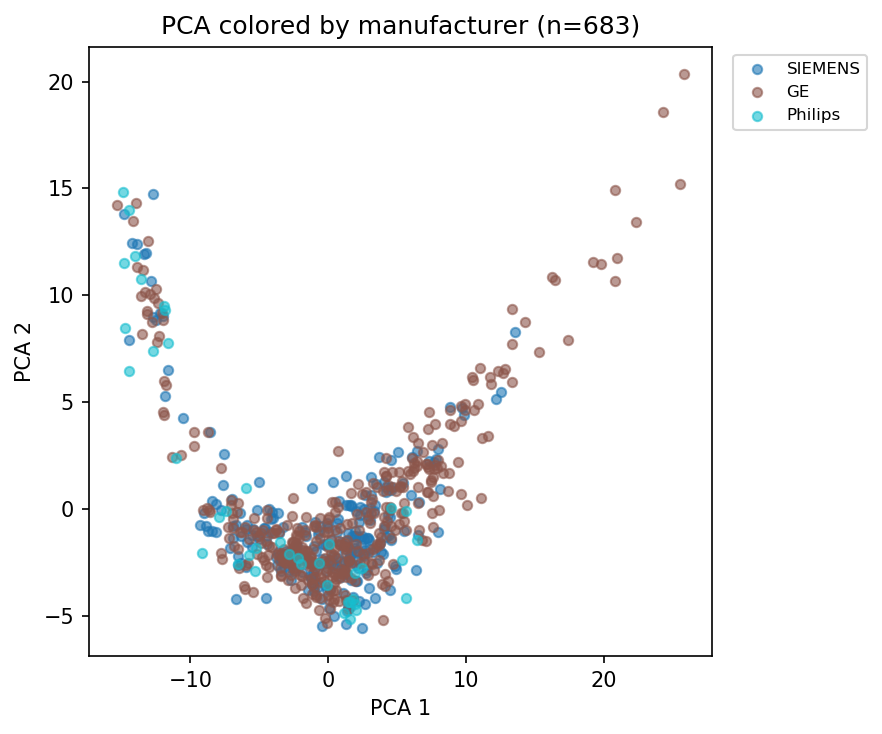

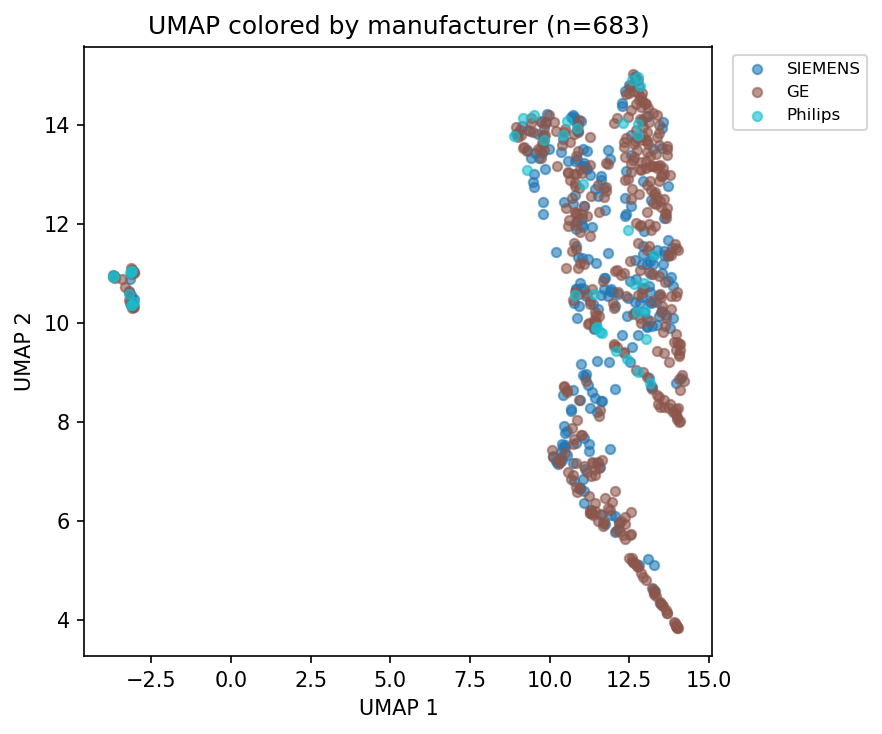

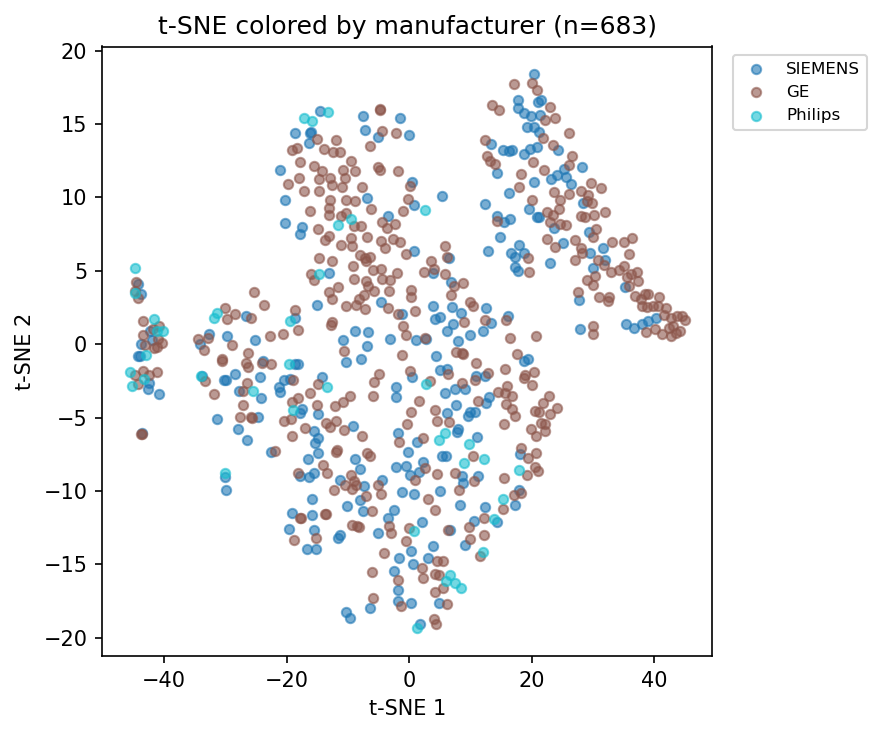

In [6]:
# PCA/UMAP/t-SNE colored by label, site, dataset, manufacturer
import json

for var in ["pcr", "site", "dataset", "manufacturer"]:
    print(f"### Colored by {var}")
    for method in ["pca", "umap", "t-sne"]:
        p = REPORT_DIR / "plots" / f"{method}_colored_by_{var}.png"
        if p.exists():
            display(Image(filename=str(p), width=480))

In [7]:
# Site prediction (batch-effect indicator)
metrics_path = REPORT_DIR / "site_prediction_metrics.json"
if metrics_path.exists():
    with metrics_path.open() as f:
        m = json.load(f)
    print(f"Site prediction AUC macro: {m['auc_macro']:.3f}")
    print(f"Interpretation: {m['interpretation']}")

Site prediction AUC macro: 0.774
Interpretation: moderate batch signal


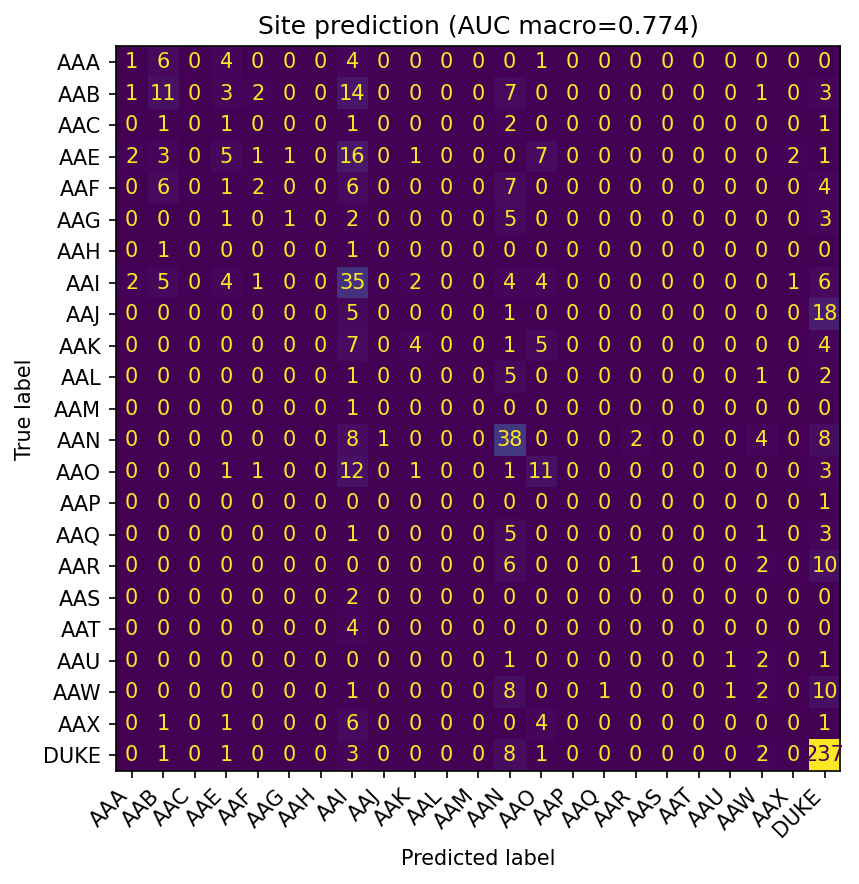

In [8]:
# Confusion matrix
conf_path = REPORT_DIR / "plots" / "site_prediction_confusion.png"
if conf_path.exists():
    display(Image(filename=str(conf_path), width=600))

## 4. Phase 4 – Ablation Study

In [9]:
abl = pd.read_csv(REPORT_DIR / "ablation_results.csv")
display(abl)

,ablation,n_features,auc,ap
0,full,113,0.516190,0.321996
1,no_coordinate_like,98,0.522381,0.360631
2,geometry_only,83,0.528095,0.312342
3,count_only,23,0.585714,0.377516


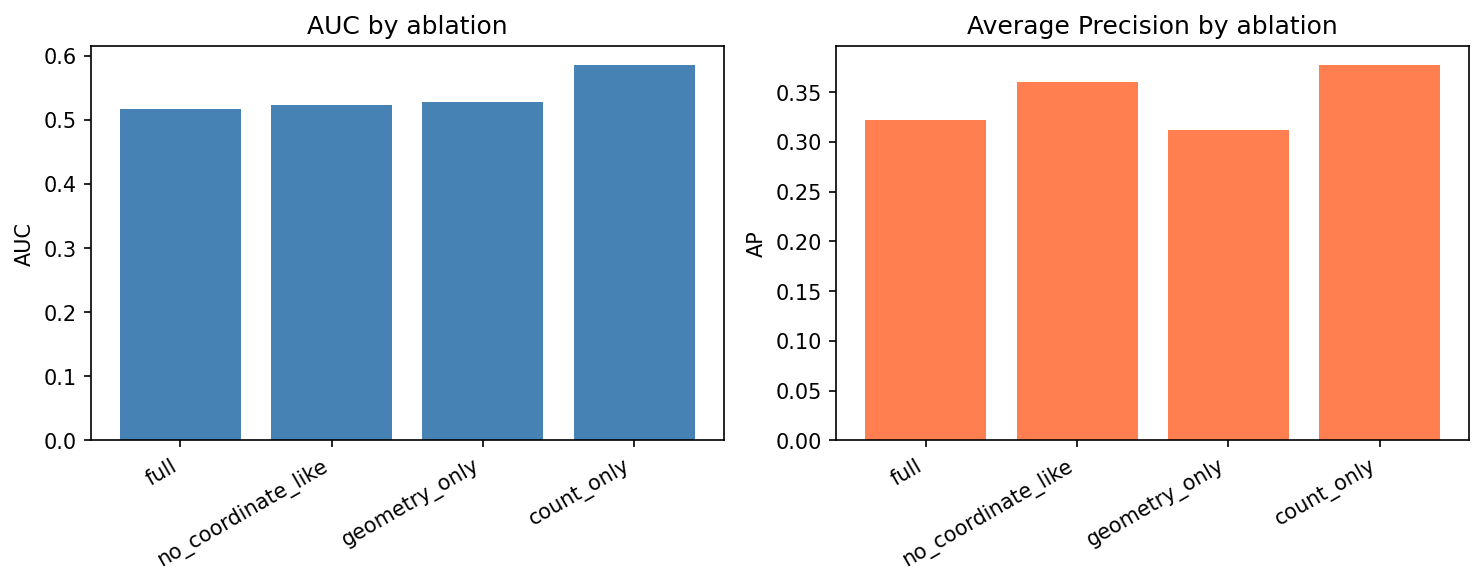

In [10]:
abl_plot = REPORT_DIR / "plots" / "ablation_auc_comparison.png"
if abl_plot.exists():
    display(Image(filename=str(abl_plot), width=700))

## 5. Phase 5 – FP/FN Case Inspection

In [11]:
fp_fn = pd.read_csv(REPORT_DIR / "fp_fn_cases.csv")
print(f"Top FP/FN: {len(fp_fn)} cases")
display(fp_fn)

Top FP/FN: 10 cases


,case_id,y_true,y_pred_proba,fp_or_fn
0,ISPY2_296841,1,0.078512,fn
1,ISPY2_317641,1,0.122443,fn
2,ISPY2_382853,1,0.128329,fn
3,ISPY2_489504,1,0.148001,fn
4,ISPY2_464547,1,0.167384,fn
5,ISPY2_128675,1,0.189076,fn
6,ISPY2_117424,1,0.192155,fn
7,DUKE_444,1,0.220889,fn
8,DUKE_633,1,0.238402,fn
9,ISPY2_208265,1,0.245504,fn


In [12]:
# Outlier summary
out_path = REPORT_DIR / "fp_fn_outliers.csv"
if out_path.exists():
    out = pd.read_csv(out_path)
    n_out = out[out["feature"] == "_n_outliers"]
    if len(n_out) > 0:
        print("Cases with extreme feature outliers (|z|>3):")
        display(n_out)
    else:
        print("Outlier rows:")
        display(out.head(15))
else:
    print("No fp_fn_outliers.csv")

Cases with extreme feature outliers (|z|>3):


,case_id,feature,value,z_score,is_outlier
9,ISPY2_317641,_n_outliers,9.0,NaN,True
16,ISPY2_382853,_n_outliers,6.0,NaN,True
18,ISPY2_208265,_n_outliers,1.0,NaN,True


fn_DUKE_444.png


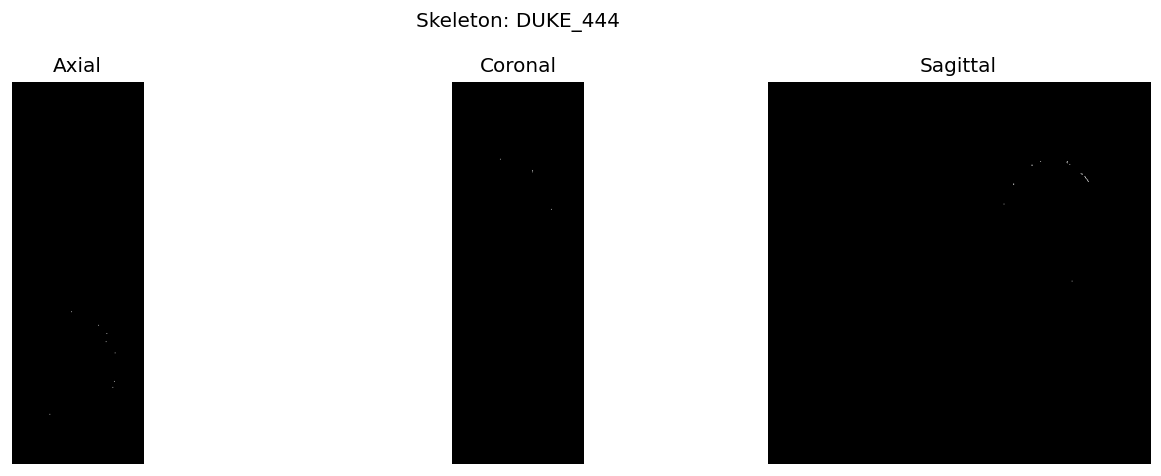

fn_DUKE_633.png


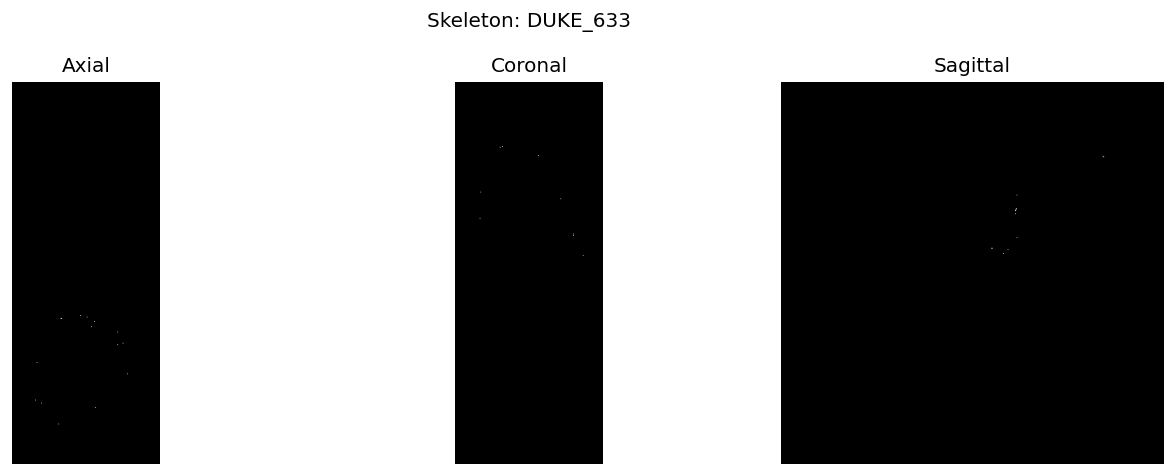

fn_ISPY2_117424.png


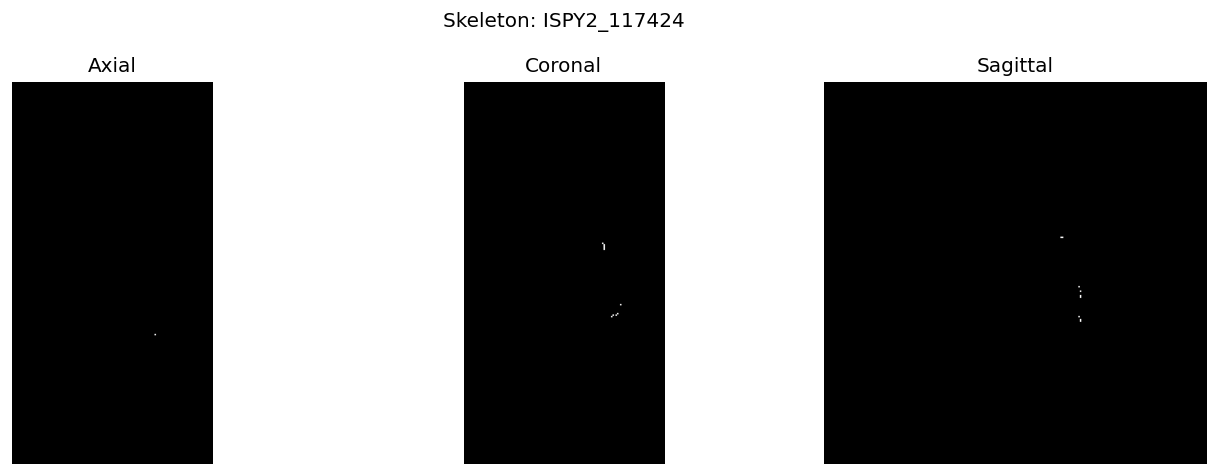

fn_ISPY2_128675.png


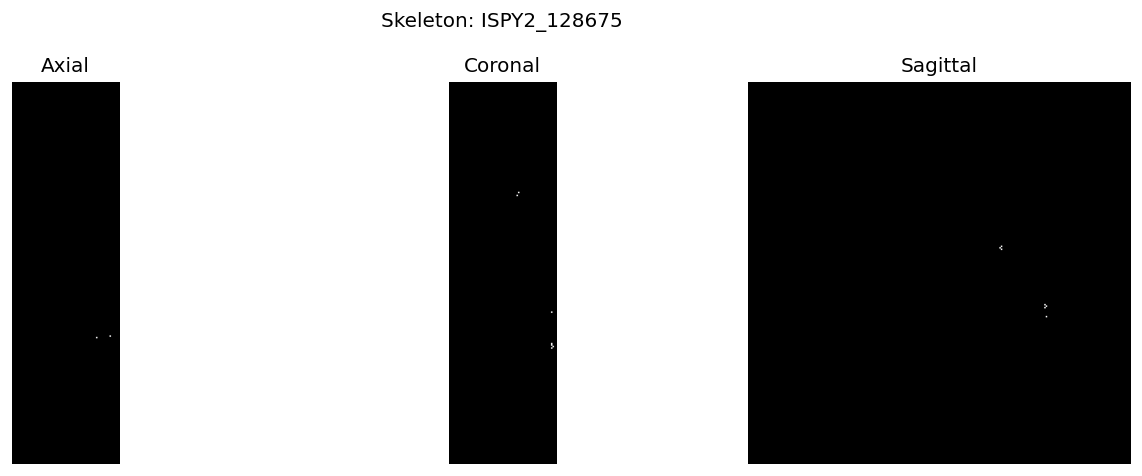

fn_ISPY2_208265.png


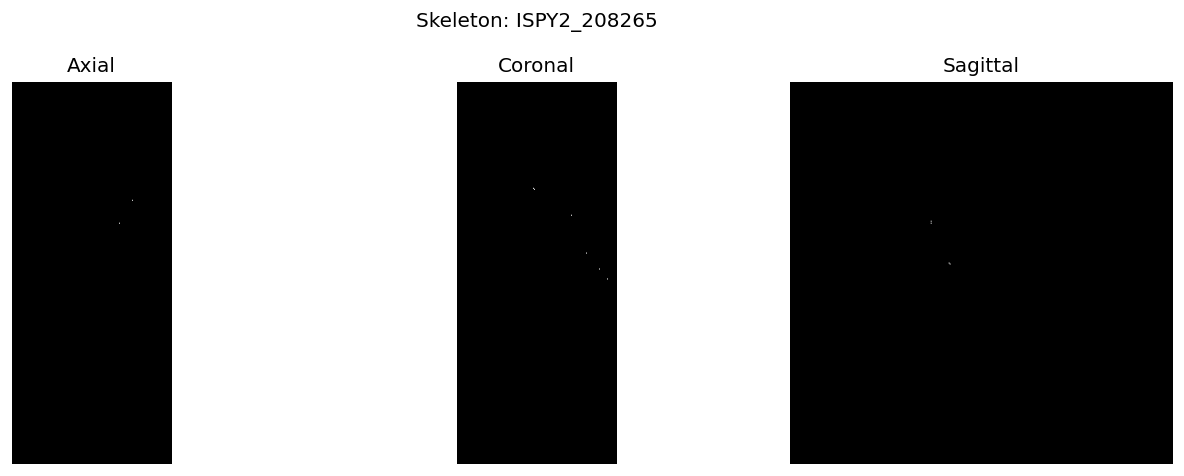

fn_ISPY2_296841.png


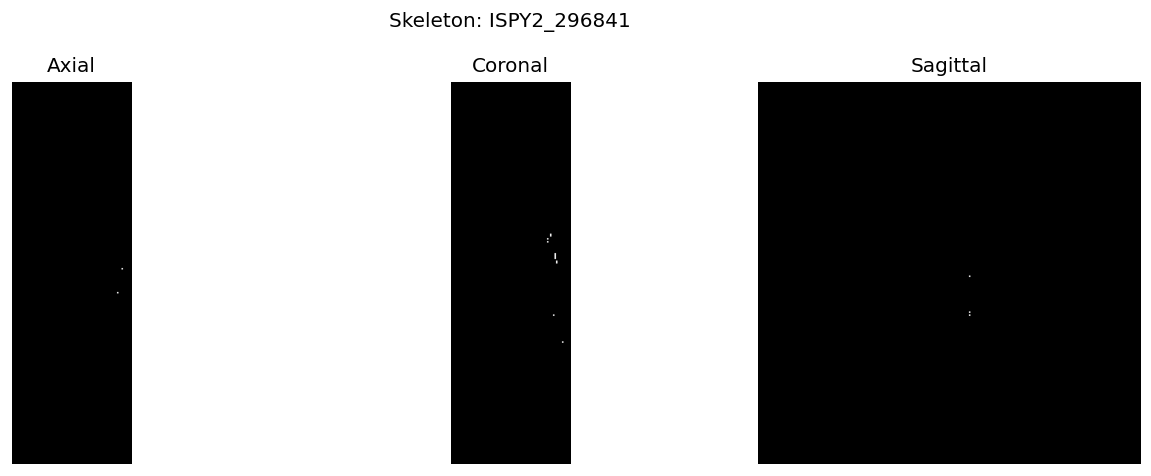

In [13]:
# Skeleton visualizations
viz_dir = REPORT_DIR / "viz"
if viz_dir.exists():
    for p in sorted(viz_dir.glob("*.png"))[:6]:
        print(p.name)
        display(Image(filename=str(p), width=400))
else:
    print("No report/viz/ directory")

## 6. Conclusion

Fill in based on the evidence above.

**Top 3 likely causes:**

1. **Cause 1** (e.g. batch effects): Evidence – site-prediction AUC, PCA clustering by site. Fix – site-stratified splits, ComBat, or site as covariate.
2. **Cause 2** (e.g. nuisance dominance): Evidence – ablation shows coordinate-like vs geometry-only. Fix – restrict to geometry subset or robust normalization.
3. **Cause 3** (e.g. low true signal): Evidence – all ablations near random, no label separation. Fix – more informative features (temporal dynamics), or accept limited signal.